In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.getcwd()

'/data/kreyno40/jzhou59/counting_code'

In [3]:
import numpy as np
import pandas as pd
from count_processing.experiment import Experiment, SelfNonTargetingExperiment
from count_processing.efficacy import EfficacyEstimator
from pathlib import Path
import logging
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv("BarcodedCounts/unfiltered/2026-04-27_V00-TPT_ACTAGG_counts.csv", index_col=0)
df

,fmt_1_37_B_MM12,fmt_1_37_B_MM13,fmt_1_37_B_MM4,fmt_1_37_C,fmt_1_37_MM8,fmt_2_104_C,fmt_2_104_MM10,fmt_2_104_MM4,fmt_2_104_MM6,fmt_3_222_B_MM2,fmt_3_222_B_MM9,fmt_3_222_C,folA_1_56_B_MM10,folA_1_56_B_MM11,folA_1_56_B_MM14,folA_1_56_B_MM2,folA_1_56_B_MM3,folA_1_56_B_MM6,folA_1_56_B_MM9,folA_1_56_C,folA_3_242_B_MM3,folA_3_242_C,folC_1_19_B_MM10,folC_1_19_B_MM4,folC_1_19_B_MM8,folC_1_19_C,folC_2_93_C,folC_2_93_MM10,folC_2_93_MM4,folC_2_93_MM6,folC_3_250_B_MM11,folC_3_250_B_MM13,folC_3_250_C,folC_3_250_MM4,folD_1_86_B_MM12,folD_1_86_B_MM13,folD_1_86_B_MM2,folD_1_86_C,folD_2_110_C,folD_2_110_MM10,folD_2_110_MM4,folD_2_110_MM6,folD_3_207_B_MM14,folD_3_207_B_MM7,folD_3_207_B_MM9,folD_3_207_C,gcvH_1_62_B_MM4,gcvH_1_62_B_MM8,gcvH_1_62_C,gcvH_1_62_MM10,gcvH_2_89_C,gcvH_2_89_MM10,gcvH_2_89_MM4,gcvH_2_89_MM6,gcvH_2_89_MM8,gcvH_3_217_B_MM4,gcvH_3_217_B_MM8,gcvH_3_217_C,gcvP_1_51_B_MM4,gcvP_1_51_B_MM8,gcvP_1_51_C,gcvP_1_51_MM10,gcvP_2_125_C,gcvP_2_125_MM10,gcvP_2_125_MM4,gcvP_2_125_MM6,gcvP_2_125_MM8,gcvP_3_224_B_MM4,gcvP_3_224_B_MM8,gcvP_3_224_C,gcvT_1_16_B_MM4,gcvT_1_16_B_MM8,gcvT_1_16_C,gcvT_1_16_MM10,gcvT_2_63_C,gcvT_2_63_MM4,gcvT_2_63_MM6,gcvT_2_63_MM8,gcvT_3_233_B_MM4,gcvT_3_233_B_MM8,gcvT_3_233_C,glyA_1_26_B_MM11,glyA_1_26_B_MM12,glyA_1_26_B_MM4,glyA_1_26_B_MM8,glyA_1_26_B_MM9,glyA_1_26_C,glyA_2_119_C,glyA_2_119_MM10,glyA_2_119_MM4,glyA_3_279_B_MM14,glyA_3_279_B_MM3,glyA_3_279_B_MM6,glyA_3_279_C,lpd_1_45_B_MM4,lpd_1_45_B_MM8,lpd_1_45_C,lpd_1_45_MM10,lpd_2_69_C,lpd_2_69_MM10,lpd_2_69_MM6,lpd_3_293_B_MM4,lpd_3_293_B_MM8,lpd_3_293_C,lpd_3_293_MM10,metF_1_17_B_MM12,metF_1_17_B_MM8,metF_1_17_B_MM9,metF_1_17_C,metF_2_45_C,metF_2_45_MM10,metF_2_45_MM4,metF_2_45_MM6,metF_3_286_B_MM4,metF_3_286_B_MM7,metF_3_286_B_MM9,metF_3_286_C,metH_1_74_B_MM4,metH_1_74_B_MM8,metH_1_74_C,metH_1_74_MM10,metH_2_128_C,metH_2_128_MM10,metH_2_128_MM4,metH_2_128_MM6,metH_2_128_MM8,metH_3_201_B_MM4,metH_3_201_B_MM8,metH_3_201_C,negC_rand_42,purH_1_16_B_MM11,purH_1_16_B_MM14,purH_1_16_B_MM5,purH_1_16_B_MM9,purH_1_16_C,purH_2_53_C,purH_2_53_MM10,purH_2_53_MM4,purH_2_53_MM6,purH_3_209_B_MM4,purH_3_209_B_MM8,purH_3_209_C,purN_1_86_B_MM12,purN_1_86_B_MM2,purN_1_86_B_MM4,purN_1_86_C,purN_2_137_C,purN_2_137_MM6,purN_3_238_B_MM10,purN_3_238_B_MM11,purN_3_238_B_MM14,purN_3_238_B_MM4,purN_3_238_B_MM5,purN_3_238_C,purN_3_238_W_MM1,purT_1_28_B_MM4,purT_1_28_B_MM8,purT_1_28_C,purT_1_28_MM10,purT_2_59_C,purT_2_59_MM10,purT_2_59_MM4,purT_2_59_MM6,purT_3_226_B_MM4,purT_3_226_B_MM8,purT_3_226_C,purU_1_129_B_MM4,purU_1_129_B_MM8,purU_1_129_C,purU_3_214_B_MM4,purU_3_214_B_MM8,purU_3_214_C,purU_5_314_C,purU_5_314_MM10,purU_5_314_MM4,purU_5_314_MM6,purU_7_360_C,purU_7_360_MM10,purU_7_360_MM6,thyA_1_60_B_MM12,thyA_1_60_B_MM13,thyA_1_60_B_MM2,thyA_1_60_C,thyA_2_111_C,thyA_2_111_MM4,thyA_2_111_MM8,thyA_3_233_B_MM4,thyA_3_233_B_MM5,thyA_3_233_B_MM6,thyA_3_233_B_MM7,thyA_3_233_C
fmt_1_37_B_MM12,141.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1206.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
fmt_1_37_B_MM13,0.0,420.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

In [5]:
df["negC_rand_42"]["negC_rand_42"]

315247.0

In [6]:
logger = logging.basicConfig(
    filename="experiment.log",
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
)

experiment = SelfNonTargetingExperiment(
    counts_directory=Path("BarcodedCounts/unfiltered"),
    vial_id="V03",
    timepoints=["T00", "T02", "T04", "T06", "T08", "T10"],
    barcodes=["TGAAAG", "CATGAT", "CCATGC", "TCATAC", "TAGACT", "ACTAGG", "Other"],
    sgRNAs=Path("PW_Folate_corrected.fa"),
    neg_control_sgRNA="negC_rand_42",
    plotting=True,
)

In [7]:
tp = experiment.read_time_library()
tp

fmt_1_37_B_MM12  fmt_1_37_B_MM13  fmt_1_37_B_MM4  \
timepoint barcode                                                     
T00       ACTAGG            1183.0           1399.0           659.0   
          CATGAT             968.0           1582.0           511.0   
          CCATGC            1065.0           1071.0           562.0   
          Other              124.0            122.0            83.0   
          TAGACT            1840.0           2253.0           587.0   
          TCATAC             838.0            697.0           530.0   
          TGAAAG             955.0           1705.0           416.0   
T02       ACTAGG            1198.0           1165.0           125.0   
          CATGAT             679.0           1285.0            90.0   
          CCATGC            1456.0           1151.0            42.0   
          Other              113.0            150.0            10.0   
          TAGACT            1801.0           2031.0           128.0   
          TCATAC             838.0            745.0            91.0   
          TGAAAG             862.0           1633.0            47.0   
T04       ACTAGG            1103.0           1195.0            44.0   
          CATGAT             707.0           1104.0            32.0   
          CCATGC             911.0            895.0            45.0   
          Other               87.0            110.0             4.0   
          TAGACT            1498.0           1670.0            64.0   
          TCATAC             661.0            667.0            34.0   
          TGAAAG             659.0           1175.0            13.0   
T06       ACTAGG            2139.0           2044.0             9.0   
          CATGAT            1252.0           1901.0            27.0   
          CCATGC            1857.0           1889.0             3.0   
          Other              217.0            225.0             2.0   
          TAGACT            3037.0           3098.0            42.0   
          TCATAC            1248.0            833.0            39.0   
          TGAAAG            1173.0           2276.0             6.0   
T08       ACTAGG            1645.0           1330.0            11.0   
          CATGAT             858.0           1264.0            25.0   
          CCATGC            1285.0           1390.0            31.0   
          Other              143.0            163.0             1.0   
          TAGACT            2056.0           2012.0            25.0   
          TCATAC             852.0            623.0             8.0   
          TGAAAG             885.0           1478.0             5.0   
T10       ACTAGG            1632.0           1414.0             2.0   
          CATGAT             771.0           1509.0            10.0   
          CCATGC            1468.0           1345.0             4.0   
          Other              144.0            174.0             0.0   
          TAGACT            2191.0           2175.0            63.0   
          TCATAC             880.0            684.0             5.0   
          TGAAAG             982.0           1595.0             3.0   

                   fmt_1_37_C  fmt_1_37_MM8  fmt_2_104_C  fmt_2_104_MM10  \
timepoint barcode                                                          
T00       ACTAGG        934.0        3743.0      20417.0         23515.0   
          CATGAT        724.0        4171.0      26192.0         29801.0   
          CCATGC        809.0        2766.0      17080.0         20486.0   
          Other          75.0         480.0       2100.0          2338.0   
          TAGACT        481.0        3866.0      20545.0         25138.0   
          TCATAC        368.0        2231.0      15195.0         17157.0   
          TGAAAG        727.0        3614.0      21846.0         22093.0   
T02       ACTAGG        307.0        1532.0       9606.0         20944.0   
          CATGAT        154.0        1301.0      10664.0         22858.0   
          CCATGC        284.0         954.0       7463.0  

In [8]:
rfs = experiment.relative_frequency(tp)

In [9]:
tn = experiment.normalize_to_t0(rfs, "T00")

In [10]:
logged = experiment.log_transform(tn)
logged

/home/jzhou59/.conda/envs/pytorch_env/lib/python3.12/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)


fmt_1_37_B_MM12  fmt_1_37_B_MM13  fmt_1_37_B_MM4  \
timepoint barcode                                                     
T00       ACTAGG          0.000000         0.000000        0.000000   
          CATGAT          0.000000         0.000000        0.000000   
          CCATGC          0.000000         0.000000        0.000000   
          Other           0.000000         0.000000        0.000000   
          TAGACT          0.000000         0.000000        0.000000   
          TCATAC          0.000000         0.000000        0.000000   
          TGAAAG          0.000000         0.000000        0.000000   
T02       ACTAGG          0.407385         0.125141       -2.009143   
          CATGAT          0.023066         0.234680       -1.970665   
          CCATGC          0.865886         0.518659       -3.327379   
          Other           0.589861         1.021960       -2.329233   
          TAGACT          0.400406         0.281656       -1.765903   
          TCATAC          0.380367         0.476449       -2.161687   
          TGAAAG          0.293684         0.379250       -2.704354   
T04       ACTAGG         -0.220991        -0.347359       -4.024677   
          CATGAT         -0.439208        -0.504921       -3.983091   
          CCATGC         -0.269440        -0.303109       -3.686683   
          Other          -0.297518         0.064357       -4.161305   
          TAGACT         -0.338645        -0.473976       -3.239194   
          TCATAC         -0.424639        -0.145811       -4.044724   
          TGAAAG         -0.637454        -0.639343       -5.102232   
T06       ACTAGG          0.270238        -0.037249       -6.778458   
          CATGAT         -0.091463        -0.197610       -4.704911   
          CCATGC          0.324782         0.341326       -8.026802   
          Other           0.346613         0.422302       -5.835781   
          TAGACT          0.191314        -0.072137       -4.336526   
          TCATAC         -0.027392        -0.344830       -4.366434   
          TGAAAG         -0.236042        -0.115944       -6.648150   
T08       ACTAGG         -0.074912        -0.623519       -6.455253   
          CATGAT         -0.544230        -0.693954       -4.723524   
          CCATGC         -0.151311        -0.046100       -4.602456   
          Other          -0.050029         0.162287       -6.630744   
          TAGACT         -0.306941        -0.630292       -5.020436   
          TCATAC         -0.495029        -0.680859       -6.568781   
          TGAAAG         -0.597666        -0.693968       -6.866354   
T10       ACTAGG         -0.074367        -0.523172       -8.902693   
          CATGAT         -0.733116        -0.472997       -6.080092   
          CCATGC          0.071380        -0.062971       -7.526045   
          Other          -0.129633         0.166845            -inf   
          TAGACT         -0.191804        -0.494520       -3.663625   
          TCATAC         -0.445089        -0.542804       -7.243563   
          TGAAAG         -0.454006        -0.590444       -7.609706   

                   fmt_1_37_C  fmt_1_37_MM8  fmt_2_104_C  fmt_2_104_MM10  \
timepoint barcode                                                          
T00       ACTAGG     0.000000      0.000000     0.000000        0.000000   
          CATGAT     0.000000      0.000000     0.000000        0.000000   
          CCATGC     0.000000      0.000000     0.000000        0.000000   
          Other      0.000000      0.000000     0.000000        0.000000   
          TAGACT     0.000000      0.000000     0.000000        0.000000   
          TCATAC     0.000000      0.000000     0.000000        0.000000   
          TGAAAG     0.000000      0.000000     0.000000        0.000000   
T02       ACTAGG    -1.215977     -0.899572    -0.698556        0.222163   
          CATGAT    -1.698398     -1.146111    -0.761716        0.152000   
          CCATGC    -1.095519     -1.121010    -0.779751  

In [11]:
logged.xs(key="ACTAGG", level="barcode")

,fmt_1_37_B_MM12,fmt_1_37_B_MM13,fmt_1_37_B_MM4,fmt_1_37_C,fmt_1_37_MM8,fmt_2_104_C,fmt_2_104_MM10,fmt_2_104_MM4,fmt_2_104_MM6,fmt_3_222_B_MM2,fmt_3_222_B_MM9,fmt_3_222_C,folA_1_56_B_MM10,folA_1_56_B_MM11,folA_1_56_B_MM14,folA_1_56_B_MM2,folA_1_56_B_MM3,folA_1_56_B_MM6,folA_1_56_B_MM9,folA_1_56_C,folA_3_242_B_MM3,folA_3_242_C,folC_1_19_B_MM10,folC_1_19_B_MM4,folC_1_19_B_MM8,folC_1_19_C,folC_2_93_C,folC_2_93_MM10,folC_2_93_MM4,folC_2_93_MM6,folC_3_250_B_MM11,folC_3_250_B_MM13,folC_3_250_C,folC_3_250_MM4,folD_1_86_B_MM12,folD_1_86_B_MM13,folD_1_86_B_MM2,folD_1_86_C,folD_2_110_C,folD_2_110_MM10,folD_2_110_MM4,folD_2_110_MM6,folD_3_207_B_MM14,folD_3_207_B_MM7,folD_3_207_B_MM9,folD_3_207_C,gcvH_1_62_B_MM4,gcvH_1_62_B_MM8,gcvH_1_62_C,gcvH_1_62_MM10,gcvH_2_89_C,gcvH_2_89_MM10,gcvH_2_89_MM4,gcvH_2_89_MM6,gcvH_2_89_MM8,gcvH_3_217_B_MM4,gcvH_3_217_B_MM8,gcvH_3_217_C,gcvP_1_51_B_MM4,gcvP_1_51_B_MM8,gcvP_1_51_C,gcvP_1_51_MM10,gcvP_2_125_C,gcvP_2_125_MM10,gcvP_2_125_MM4,gcvP_2_125_MM6,gcvP_2_125_MM8,gcvP_3_224_B_MM4,gcvP_3_224_B_MM8,gcvP_3_224_C,gcvT_1_16_B_MM4,gcvT_1_16_B_MM8,gcvT_1_16_C,gcvT_1_16_MM10,gcvT_2_63_C,gcvT_2_63_MM4,gcvT_2_63_MM6,gcvT_2_63_MM8,gcvT_3_233_B_MM4,gcvT_3_233_B_MM8,gcvT_3_233_C,glyA_1_26_B_MM11,glyA_1_26_B_MM12,glyA_1_26_B_MM4,glyA_1_26_B_MM8,glyA_1_26_B_MM9,glyA_1_26_C,glyA_2_119_C,glyA_2_119_MM10,glyA_2_119_MM4,glyA_3_279_B_MM14,glyA_3_279_B_MM3,glyA_3_279_B_MM6,glyA_3_279_C,lpd_1_45_B_MM4,lpd_1_45_B_MM8,lpd_1_45_C,lpd_1_45_MM10,lpd_2_69_C,lpd_2_69_MM10,lpd_2_69_MM6,lpd_3_293_B_MM4,lpd_3_293_B_MM8,lpd_3_293_C,lpd_3_293_MM10,metF_1_17_B_MM12,metF_1_17_B_MM8,metF_1_17_B_MM9,metF_1_17_C,metF_2_45_C,metF_2_45_MM10,metF_2_45_MM4,metF_2_45_MM6,metF_3_286_B_MM4,metF_3_286_B_MM7,metF_3_286_B_MM9,metF_3_286_C,metH_1_74_B_MM4,metH_1_74_B_MM8,metH_1_74_C,metH_1_74_MM10,metH_2_128_C,metH_2_128_MM10,metH_2_128_MM4,metH_2_128_MM6,metH_2_128_MM8,metH_3_201_B_MM4,metH_3_201_B_MM8,metH_3_201_C,negC_rand_42,purH_1_16_B_MM11,purH_1_16_B_MM14,purH_1_16_B_MM5,purH_1_16_B_MM9,purH_1_16_C,purH_2_53_C,purH_2_53_MM10,purH_2_53_MM4,purH_2_53_MM6,purH_3_209_B_MM4,purH_3_209_B_MM8,purH_3_209_C,purN_1_86_B_MM12,purN_1_86_B_MM2,purN_1_86_B_MM4,purN_1_86_C,purN_2_137_C,purN_2_137_MM6,purN_3_238_B_MM10,purN_3_238_B_MM11,purN_3_238_B_MM14,purN_3_238_B_MM4,purN_3_238_B_MM5,purN_3_238_C,purN_3_238_W_MM1,purT_1_28_B_MM4,purT_1_28_B_MM8,purT_1_28_C,purT_1_28_MM10,purT_2_59_C,purT_2_59_MM10,purT_2_59_MM4,purT_2_59_MM6,purT_3_226_B_MM4,purT_3_226_B_MM8,purT_3_226_C,purU_1_129_B_MM4,purU_1_129_B_MM8,purU_1_129_C,purU_3_214_B_MM4,purU_3_214_B_MM8,purU_3_214_C,purU_5_314_C,purU_5_314_MM10,purU_5_314_MM4,purU_5_314_MM6,purU_7_360_C,purU_7_360_MM10,purU_7_360_MM6,thyA_1_60_B_MM12,thyA_1_60_B_MM13,thyA_1_60_B_MM2,thyA_1_60_C,thyA_2_111_C,thyA_2_111_MM4,thyA_2_111_MM8,thyA_3_233_B_MM4,thyA_3_233_B_MM5,thyA_3_233_B_MM6,thyA_3_233_B_MM7,thyA_3_233_C
timepoint,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
T00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,

In [12]:
growth_rates = experiment.growth_rates(logged, 
{"T00": 0, "T02": 2, "T04": 4, "T06": 6, "T08": 8, "T10": 10}
)

In [13]:
growth_rates

,fmt_1_37_B_MM12,fmt_1_37_B_MM13,fmt_1_37_B_MM4,fmt_1_37_C,fmt_1_37_MM8,fmt_2_104_C,fmt_2_104_MM10,fmt_2_104_MM4,fmt_2_104_MM6,fmt_3_222_B_MM2,fmt_3_222_B_MM9,fmt_3_222_C,folA_1_56_B_MM10,folA_1_56_B_MM11,folA_1_56_B_MM14,folA_1_56_B_MM2,folA_1_56_B_MM3,folA_1_56_B_MM6,folA_1_56_B_MM9,folA_1_56_C,folA_3_242_B_MM3,folA_3_242_C,folC_1_19_B_MM10,folC_1_19_B_MM4,folC_1_19_B_MM8,folC_1_19_C,folC_2_93_C,folC_2_93_MM10,folC_2_93_MM4,folC_2_93_MM6,folC_3_250_B_MM11,folC_3_250_B_MM13,folC_3_250_C,folC_3_250_MM4,folD_1_86_B_MM12,folD_1_86_B_MM13,folD_1_86_B_MM2,folD_1_86_C,folD_2_110_C,folD_2_110_MM10,folD_2_110_MM4,folD_2_110_MM6,folD_3_207_B_MM14,folD_3_207_B_MM7,folD_3_207_B_MM9,folD_3_207_C,gcvH_1_62_B_MM4,gcvH_1_62_B_MM8,gcvH_1_62_C,gcvH_1_62_MM10,gcvH_2_89_C,gcvH_2_89_MM10,gcvH_2_89_MM4,gcvH_2_89_MM6,gcvH_2_89_MM8,gcvH_3_217_B_MM4,gcvH_3_217_B_MM8,gcvH_3_217_C,gcvP_1_51_B_MM4,gcvP_1_51_B_MM8,gcvP_1_51_C,gcvP_1_51_MM10,gcvP_2_125_C,gcvP_2_125_MM10,gcvP_2_125_MM4,gcvP_2_125_MM6,gcvP_2_125_MM8,gcvP_3_224_B_MM4,gcvP_3_224_B_MM8,gcvP_3_224_C,gcvT_1_16_B_MM4,gcvT_1_16_B_MM8,gcvT_1_16_C,gcvT_1_16_MM10,gcvT_2_63_C,gcvT_2_63_MM4,gcvT_2_63_MM6,gcvT_2_63_MM8,gcvT_3_233_B_MM4,gcvT_3_233_B_MM8,gcvT_3_233_C,glyA_1_26_B_MM11,glyA_1_26_B_MM12,glyA_1_26_B_MM4,glyA_1_26_B_MM8,glyA_1_26_B_MM9,glyA_1_26_C,glyA_2_119_C,glyA_2_119_MM10,glyA_2_119_MM4,glyA_3_279_B_MM14,glyA_3_279_B_MM3,glyA_3_279_B_MM6,glyA_3_279_C,lpd_1_45_B_MM4,lpd_1_45_B_MM8,lpd_1_45_C,lpd_1_45_MM10,lpd_2_69_C,lpd_2_69_MM10,lpd_2_69_MM6,lpd_3_293_B_MM4,lpd_3_293_B_MM8,lpd_3_293_C,lpd_3_293_MM10,metF_1_17_B_MM12,metF_1_17_B_MM8,metF_1_17_B_MM9,metF_1_17_C,metF_2_45_C,metF_2_45_MM10,metF_2_45_MM4,metF_2_45_MM6,metF_3_286_B_MM4,metF_3_286_B_MM7,metF_3_286_B_MM9,metF_3_286_C,metH_1_74_B_MM4,metH_1_74_B_MM8,metH_1_74_C,metH_1_74_MM10,metH_2_128_C,metH_2_128_MM10,metH_2_128_MM4,metH_2_128_MM6,metH_2_128_MM8,metH_3_201_B_MM4,metH_3_201_B_MM8,metH_3_201_C,negC_rand_42,purH_1_16_B_MM11,purH_1_16_B_MM14,purH_1_16_B_MM5,purH_1_16_B_MM9,purH_1_16_C,purH_2_53_C,purH_2_53_MM10,purH_2_53_MM4,purH_2_53_MM6,purH_3_209_B_MM4,purH_3_209_B_MM8,purH_3_209_C,purN_1_86_B_MM12,purN_1_86_B_MM2,purN_1_86_B_MM4,purN_1_86_C,purN_2_137_C,purN_2_137_MM6,purN_3_238_B_MM10,purN_3_238_B_MM11,purN_3_238_B_MM14,purN_3_238_B_MM4,purN_3_238_B_MM5,purN_3_238_C,purN_3_238_W_MM1,purT_1_28_B_MM4,purT_1_28_B_MM8,purT_1_28_C,purT_1_28_MM10,purT_2_59_C,purT_2_59_MM10,purT_2_59_MM4,purT_2_59_MM6,purT_3_226_B_MM4,purT_3_226_B_MM8,purT_3_226_C,purU_1_129_B_MM4,purU_1_129_B_MM8,purU_1_129_C,purU_3_214_B_MM4,purU_3_214_B_MM8,purU_3_214_C,purU_5_314_C,purU_5_314_MM10,purU_5_314_MM4,purU_5_314_MM6,purU_7_360_C,purU_7_360_MM10,purU_7_360_MM6,thyA_1_60_B_MM12,thyA_1_60_B_MM13,thyA_1_60_B_MM2,thyA_1_60_C,thyA_2_111_C,thyA_2_111_MM4,thyA_2_111_MM8,thyA_3_233_B_MM4,thyA_3_233_B_MM5,thyA_3_233_B_MM6,thyA_3_233_B_MM7,thyA_3_233_C
barcode,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ACTAGG,-0.018964,-0.065025,-0.865794,-0.515074,-0.433873,-0.341270,-0.059386,-0.242534,-0.268957,-0.646504,-0.315685,-0.693541,-0.017136,0.014706,0.032060,-0.258649,-0.479560,-0.010856,-0.439726,-0.280418,0.000983,-0.218635,0.002216,-0.475016,-0.018094,-0.708935,-0.034923,0.009229,-0.008267,0.001776,-0.445982,-0.096212,-0.591363,-0.570961,-0.064587,0.014115,-0.820730,-0.156342,-0.492005,-0.246907,-0.508559,-0.242485,0.072417,-0.452260,-0.194590,-0.297725,0.031950,0.014906,0.013043,0.015910,0.031467,-0.052772,-0.022242,0.013157,0.017205,0.016087,0.046582,0.010386,-0.006736,-0.046825,-0.004355,0.029019,-0.055123,0.014638,-0.043000,-0.024726,-0.060344,0.009728,-0.020565,-0.029881,-0.013253,-0.021804,0.030252,-0.006416,-0.008706,-0.041460,-0.031029,-0.016906,-0.036392,-0.019420,-0.033599,-0.007034,-0.119388,-0.421327,-0.418061,-0.300355,-0.562255,-0.241335,-0.187537,-0.300919,0.001497,-0.230511,-0.208228,-0.267110,-0.280837

In [14]:
growth_rates.loc["ACTAGG", "negC_rand_42"]

0.0

In [15]:
escaper_corrected = experiment.escaper_correction(growth_rates)

Outlier detected for folC_1_19_B_MM10 in barcode CCATGC. Applying escaper correction.
Outlier detected for folC_2_93_MM10 in barcode ACTAGG. Applying escaper correction.
Outlier detected for glyA_1_26_B_MM4 in barcode Other. Applying escaper correction.
Outlier detected for lpd_3_293_B_MM8 in barcode ACTAGG. Applying escaper correction.
Outlier detected for metF_1_17_C in barcode ACTAGG. Applying escaper correction.
Outlier detected for metH_3_201_B_MM8 in barcode CCATGC. Applying escaper correction.
Outlier detected for purN_3_238_B_MM10 in barcode CCATGC. Applying escaper correction.
Outlier detected for purU_5_314_MM10 in barcode CCATGC. Applying escaper correction.
Outlier detected for purU_7_360_C in barcode TCATAC. Applying escaper correction.
Outlier detected for thyA_2_111_C in barcode TCATAC. Applying escaper correction.


In [16]:
escaper_corrected

,fmt_1_37_B_MM12,fmt_1_37_B_MM13,fmt_1_37_B_MM4,fmt_1_37_C,fmt_1_37_MM8,fmt_2_104_C,fmt_2_104_MM10,fmt_2_104_MM4,fmt_2_104_MM6,fmt_3_222_B_MM2,fmt_3_222_B_MM9,fmt_3_222_C,folA_1_56_B_MM10,folA_1_56_B_MM11,folA_1_56_B_MM14,folA_1_56_B_MM2,folA_1_56_B_MM3,folA_1_56_B_MM6,folA_1_56_B_MM9,folA_1_56_C,folA_3_242_B_MM3,folA_3_242_C,folC_1_19_B_MM10,folC_1_19_B_MM4,folC_1_19_B_MM8,folC_1_19_C,folC_2_93_C,folC_2_93_MM10,folC_2_93_MM4,folC_2_93_MM6,folC_3_250_B_MM11,folC_3_250_B_MM13,folC_3_250_C,folC_3_250_MM4,folD_1_86_B_MM12,folD_1_86_B_MM13,folD_1_86_B_MM2,folD_1_86_C,folD_2_110_C,folD_2_110_MM10,folD_2_110_MM4,folD_2_110_MM6,folD_3_207_B_MM14,folD_3_207_B_MM7,folD_3_207_B_MM9,folD_3_207_C,gcvH_1_62_B_MM4,gcvH_1_62_B_MM8,gcvH_1_62_C,gcvH_1_62_MM10,gcvH_2_89_C,gcvH_2_89_MM10,gcvH_2_89_MM4,gcvH_2_89_MM6,gcvH_2_89_MM8,gcvH_3_217_B_MM4,gcvH_3_217_B_MM8,gcvH_3_217_C,gcvP_1_51_B_MM4,gcvP_1_51_B_MM8,gcvP_1_51_C,gcvP_1_51_MM10,gcvP_2_125_C,gcvP_2_125_MM10,gcvP_2_125_MM4,gcvP_2_125_MM6,gcvP_2_125_MM8,gcvP_3_224_B_MM4,gcvP_3_224_B_MM8,gcvP_3_224_C,gcvT_1_16_B_MM4,gcvT_1_16_B_MM8,gcvT_1_16_C,gcvT_1_16_MM10,gcvT_2_63_C,gcvT_2_63_MM4,gcvT_2_63_MM6,gcvT_2_63_MM8,gcvT_3_233_B_MM4,gcvT_3_233_B_MM8,gcvT_3_233_C,glyA_1_26_B_MM11,glyA_1_26_B_MM12,glyA_1_26_B_MM4,glyA_1_26_B_MM8,glyA_1_26_B_MM9,glyA_1_26_C,glyA_2_119_C,glyA_2_119_MM10,glyA_2_119_MM4,glyA_3_279_B_MM14,glyA_3_279_B_MM3,glyA_3_279_B_MM6,glyA_3_279_C,lpd_1_45_B_MM4,lpd_1_45_B_MM8,lpd_1_45_C,lpd_1_45_MM10,lpd_2_69_C,lpd_2_69_MM10,lpd_2_69_MM6,lpd_3_293_B_MM4,lpd_3_293_B_MM8,lpd_3_293_C,lpd_3_293_MM10,metF_1_17_B_MM12,metF_1_17_B_MM8,metF_1_17_B_MM9,metF_1_17_C,metF_2_45_C,metF_2_45_MM10,metF_2_45_MM4,metF_2_45_MM6,metF_3_286_B_MM4,metF_3_286_B_MM7,metF_3_286_B_MM9,metF_3_286_C,metH_1_74_B_MM4,metH_1_74_B_MM8,metH_1_74_C,metH_1_74_MM10,metH_2_128_C,metH_2_128_MM10,metH_2_128_MM4,metH_2_128_MM6,metH_2_128_MM8,metH_3_201_B_MM4,metH_3_201_B_MM8,metH_3_201_C,negC_rand_42,purH_1_16_B_MM11,purH_1_16_B_MM14,purH_1_16_B_MM5,purH_1_16_B_MM9,purH_1_16_C,purH_2_53_C,purH_2_53_MM10,purH_2_53_MM4,purH_2_53_MM6,purH_3_209_B_MM4,purH_3_209_B_MM8,purH_3_209_C,purN_1_86_B_MM12,purN_1_86_B_MM2,purN_1_86_B_MM4,purN_1_86_C,purN_2_137_C,purN_2_137_MM6,purN_3_238_B_MM10,purN_3_238_B_MM11,purN_3_238_B_MM14,purN_3_238_B_MM4,purN_3_238_B_MM5,purN_3_238_C,purN_3_238_W_MM1,purT_1_28_B_MM4,purT_1_28_B_MM8,purT_1_28_C,purT_1_28_MM10,purT_2_59_C,purT_2_59_MM10,purT_2_59_MM4,purT_2_59_MM6,purT_3_226_B_MM4,purT_3_226_B_MM8,purT_3_226_C,purU_1_129_B_MM4,purU_1_129_B_MM8,purU_1_129_C,purU_3_214_B_MM4,purU_3_214_B_MM8,purU_3_214_C,purU_5_314_C,purU_5_314_MM10,purU_5_314_MM4,purU_5_314_MM6,purU_7_360_C,purU_7_360_MM10,purU_7_360_MM6,thyA_1_60_B_MM12,thyA_1_60_B_MM13,thyA_1_60_B_MM2,thyA_1_60_C,thyA_2_111_C,thyA_2_111_MM4,thyA_2_111_MM8,thyA_3_233_B_MM4,thyA_3_233_B_MM5,thyA_3_233_B_MM6,thyA_3_233_B_MM7,thyA_3_233_C
barcode,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ACTAGG,-0.018964,-0.065025,-0.865794,-0.515074,-0.433873,-0.341270,-0.059386,-0.242534,-0.268957,-0.646504,-0.315685,-0.693541,-0.017136,0.014706,0.032060,-0.258649,-0.479560,-0.010856,-0.439726,-0.280418,0.000983,-0.218635,0.002216,-0.475016,-0.018094,-0.708935,-0.034923,NaN,-0.008267,0.001776,-0.445982,-0.096212,-0.591363,-0.570961,-0.064587,0.014115,-0.820730,-0.156342,-0.492005,-0.246907,-0.508559,-0.242485,0.072417,-0.452260,-0.194590,-0.297725,0.031950,0.014906,0.013043,0.015910,0.031467,-0.052772,-0.022242,0.013157,0.017205,0.016087,0.046582,0.010386,-0.006736,-0.046825,-0.004355,0.029019,-0.055123,0.014638,-0.043000,-0.024726,-0.060344,0.009728,-0.020565,-0.029881,-0.013253,-0.021804,0.030252,-0.006416,-0.008706,-0.041460,-0.031029,-0.016906,-0.036392,-0.019420,-0.033599,-0.007034,-0.119388,-0.421327,-0.418061,-0.300355,-0.562255,-0.241335,-0.187537,-0.300919,0.001497,-0.230511,-0.208228,-0.267110,-0.280837,-0.2

In [17]:
agr = experiment.average_growth_rates(escaper_corrected)

In [18]:
agr

,fmt_1_37_B_MM12,fmt_1_37_B_MM13,fmt_1_37_B_MM4,fmt_1_37_C,fmt_1_37_MM8,fmt_2_104_C,fmt_2_104_MM10,fmt_2_104_MM4,fmt_2_104_MM6,fmt_3_222_B_MM2,fmt_3_222_B_MM9,fmt_3_222_C,folA_1_56_B_MM10,folA_1_56_B_MM11,folA_1_56_B_MM14,folA_1_56_B_MM2,folA_1_56_B_MM3,folA_1_56_B_MM6,folA_1_56_B_MM9,folA_1_56_C,folA_3_242_B_MM3,folA_3_242_C,folC_1_19_B_MM10,folC_1_19_B_MM4,folC_1_19_B_MM8,folC_1_19_C,folC_2_93_C,folC_2_93_MM10,folC_2_93_MM4,folC_2_93_MM6,folC_3_250_B_MM11,folC_3_250_B_MM13,folC_3_250_C,folC_3_250_MM4,folD_1_86_B_MM12,folD_1_86_B_MM13,folD_1_86_B_MM2,folD_1_86_C,folD_2_110_C,folD_2_110_MM10,folD_2_110_MM4,folD_2_110_MM6,folD_3_207_B_MM14,folD_3_207_B_MM7,folD_3_207_B_MM9,folD_3_207_C,gcvH_1_62_B_MM4,gcvH_1_62_B_MM8,gcvH_1_62_C,gcvH_1_62_MM10,gcvH_2_89_C,gcvH_2_89_MM10,gcvH_2_89_MM4,gcvH_2_89_MM6,gcvH_2_89_MM8,gcvH_3_217_B_MM4,gcvH_3_217_B_MM8,gcvH_3_217_C,gcvP_1_51_B_MM4,gcvP_1_51_B_MM8,gcvP_1_51_C,gcvP_1_51_MM10,gcvP_2_125_C,gcvP_2_125_MM10,gcvP_2_125_MM4,gcvP_2_125_MM6,gcvP_2_125_MM8,gcvP_3_224_B_MM4,gcvP_3_224_B_MM8,gcvP_3_224_C,gcvT_1_16_B_MM4,gcvT_1_16_B_MM8,gcvT_1_16_C,gcvT_1_16_MM10,gcvT_2_63_C,gcvT_2_63_MM4,gcvT_2_63_MM6,gcvT_2_63_MM8,gcvT_3_233_B_MM4,gcvT_3_233_B_MM8,gcvT_3_233_C,glyA_1_26_B_MM11,glyA_1_26_B_MM12,glyA_1_26_B_MM4,glyA_1_26_B_MM8,glyA_1_26_B_MM9,glyA_1_26_C,glyA_2_119_C,glyA_2_119_MM10,glyA_2_119_MM4,glyA_3_279_B_MM14,glyA_3_279_B_MM3,glyA_3_279_B_MM6,glyA_3_279_C,lpd_1_45_B_MM4,lpd_1_45_B_MM8,lpd_1_45_C,lpd_1_45_MM10,lpd_2_69_C,lpd_2_69_MM10,lpd_2_69_MM6,lpd_3_293_B_MM4,lpd_3_293_B_MM8,lpd_3_293_C,lpd_3_293_MM10,metF_1_17_B_MM12,metF_1_17_B_MM8,metF_1_17_B_MM9,metF_1_17_C,metF_2_45_C,metF_2_45_MM10,metF_2_45_MM4,metF_2_45_MM6,metF_3_286_B_MM4,metF_3_286_B_MM7,metF_3_286_B_MM9,metF_3_286_C,metH_1_74_B_MM4,metH_1_74_B_MM8,metH_1_74_C,metH_1_74_MM10,metH_2_128_C,metH_2_128_MM10,metH_2_128_MM4,metH_2_128_MM6,metH_2_128_MM8,metH_3_201_B_MM4,metH_3_201_B_MM8,metH_3_201_C,negC_rand_42,purH_1_16_B_MM11,purH_1_16_B_MM14,purH_1_16_B_MM5,purH_1_16_B_MM9,purH_1_16_C,purH_2_53_C,purH_2_53_MM10,purH_2_53_MM4,purH_2_53_MM6,purH_3_209_B_MM4,purH_3_209_B_MM8,purH_3_209_C,purN_1_86_B_MM12,purN_1_86_B_MM2,purN_1_86_B_MM4,purN_1_86_C,purN_2_137_C,purN_2_137_MM6,purN_3_238_B_MM10,purN_3_238_B_MM11,purN_3_238_B_MM14,purN_3_238_B_MM4,purN_3_238_B_MM5,purN_3_238_C,purN_3_238_W_MM1,purT_1_28_B_MM4,purT_1_28_B_MM8,purT_1_28_C,purT_1_28_MM10,purT_2_59_C,purT_2_59_MM10,purT_2_59_MM4,purT_2_59_MM6,purT_3_226_B_MM4,purT_3_226_B_MM8,purT_3_226_C,purU_1_129_B_MM4,purU_1_129_B_MM8,purU_1_129_C,purU_3_214_B_MM4,purU_3_214_B_MM8,purU_3_214_C,purU_5_314_C,purU_5_314_MM10,purU_5_314_MM4,purU_5_314_MM6,purU_7_360_C,purU_7_360_MM10,purU_7_360_MM6,thyA_1_60_B_MM12,thyA_1_60_B_MM13,thyA_1_60_B_MM2,thyA_1_60_C,thyA_2_111_C,thyA_2_111_MM4,thyA_2_111_MM8,thyA_3_233_B_MM4,thyA_3_233_B_MM5,thyA_3_233_B_MM6,thyA_3_233_B_MM7,thyA_3_233_C
mean,-0.044734,-0.059157,-0.684674,-0.587631,-0.431520,-0.358317,-0.062481,-0.257295,-0.312435,-0.571854,-0.297983,-0.537496,-0.025165,0.006362,0.019994,-0.445989,-0.421554,-0.175856,-0.460462,-0.567566,-0.010024,-0.144483,0.009769,-0.530609,0.000906,-0.590392,-0.046408,-0.011900,-0.018298,0.009323,-0.369603,-0.101943,-0.533885,-0.510705,-0.061352,-0.018701,-0.542364,-0.217370,-0.385393,-0.171985,-0.385124,-0.264406,0.053266,-0.328939,-0.174583,-0.475257,0.010084,0.007967,0.006572,0.011270,-0.007340,-0.039624,-0.013814,0.018519,0.010407,-0.003754,0.041474,0.007202,0.006539,-0.024530,-0.007798,0.005631,-0.045051,-0.002630,-0.013720,-0.014939,-0.049668,0.011340,-0.002543,-0.032192,-0.014131,-0.011648,0.006426,-0.014278,-0.014140,-0.058173,-0.046045,-0.034974,-0.052426,-0.012997,-0.008606,-0.025442,-0.139658,-0.414113,-0.346471,-0.347652,-0.394420,-0.247428,-0.172334,-0.298452,0.018988,-0.281659,-0.197118,-0.184752,-0.276439,-0.294233,-0.295213,-0.201522,-0.254039,-0.037446,-0.128174,-0.254457,-0.310880,-0.326756,-0.162263,0.051685,0.012483,0.004753,-0.188260,-0.013890,-0.181973,-0.024962,-0.011471,-0.036649,-0.018550

In [19]:
agr.sort_values(by="mean", axis=1)

,fmt_1_37_B_MM4,folC_1_19_C,fmt_1_37_C,fmt_3_222_B_MM2,purH_1_16_B_MM5,folA_1_56_C,folD_1_86_B_MM2,fmt_3_222_C,folC_3_250_C,folC_1_19_B_MM4,folC_3_250_MM4,purT_1_28_MM10,thyA_2_111_C,folD_3_207_C,folA_1_56_B_MM9,thyA_2_111_MM4,folA_1_56_B_MM2,fmt_1_37_MM8,folA_1_56_B_MM3,glyA_1_26_B_MM4,purH_1_16_C,glyA_1_26_C,folD_2_110_C,folD_2_110_MM4,purH_2_53_C,folC_3_250_B_MM11,fmt_2_104_C,glyA_1_26_B_MM9,glyA_1_26_B_MM8,purH_2_53_MM4,purN_1_86_B_MM4,folD_3_207_B_MM7,lpd_3_293_C,purH_1_16_B_MM11,purH_2_53_MM6,purH_1_16_B_MM9,fmt_2_104_MM6,lpd_3_293_B_MM8,glyA_2_119_MM4,fmt_3_222_B_MM9,lpd_1_45_C,lpd_1_45_B_MM8,purU_5_314_MM6,glyA_3_279_B_MM3,lpd_1_45_B_MM4,purN_1_86_B_MM2,folD_2_110_MM6,fmt_2_104_MM4,lpd_3_293_B_MM4,lpd_2_69_C,glyA_2_119_C,purN_3_238_W_MM1,purN_3_238_C,purH_3_209_B_MM4,purN_2_137_C,purN_3_238_B_MM4,purN_2_137_MM6,folD_1_86_C,purN_1_86_C,purU_5_314_C,purH_3_209_C,lpd_1_45_MM10,glyA_3_279_B_MM6,metF_1_17_C,glyA_3_279_C,metF_2_45_MM10,purU_5_314_MM4,folA_1_56_B_MM6,folD_3_207_B_MM9,glyA_2_119_MM10,thyA_1_60_B_MM12,folD_2_110_MM10,purN_3_238_B_MM5,lpd_3_293_MM10,folA_3_242_C,glyA_1_26_B_MM12,lpd_2_69_MM6,folC_3_250_B_MM13,purU_1_129_B_MM4,purU_1_129_C,thyA_1_60_C,purU_1_129_B_MM8,purU_5_314_MM10,thyA_1_60_B_MM2,purN_3_238_B_MM10,purT_3_226_B_MM4,purU_7_360_MM6,purT_3_226_B_MM8,purU_7_360_MM10,metH_2_128_MM4,fmt_2_104_MM10,folD_1_86_B_MM12,fmt_1_37_B_MM13,gcvT_2_63_MM4,metH_2_128_MM6,gcvT_3_233_B_MM4,gcvP_2_125_MM8,folC_2_93_C,gcvT_2_63_MM6,gcvP_2_125_C,fmt_1_37_B_MM12,purU_7_360_C,metH_1_74_B_MM4,gcvH_2_89_MM10,lpd_2_69_MM10,purT_2_59_MM6,metF_3_286_B_MM4,gcvT_2_63_MM8,metH_2_128_C,purN_3_238_B_MM14,gcvP_3_224_C,metH_1_74_C,purT_2_59_MM4,purT_2_59_MM10,glyA_1_26_B_MM11,folA_1_56_B_MM10,metF_2_45_MM4,gcvP_1_51_B_MM8,purH_3_209_B_MM8,purT_1_28_C,purT_1_28_B_MM8,metH_2_128_MM8,purH_2_53_MM10,metH_3_201_B_MM8,folD_1_86_B_MM13,metF_3_286_B_MM7,folC_2_93_MM4,purT_2_59_C,metH_2_128_MM10,purU_3_214_B_MM4,gcvP_2_125_MM6,gcvT_1_16_MM10,gcvT_2_63_C,gcvT_1_16_B_MM4,metF_2_45_C,gcvH_2_89_MM4,gcvP_2_125_MM4,purU_3_214_B_MM8,gcvT_3_233_B_MM8,folC_2_93_MM10,gcvT_1_16_B_MM8,metF_2_45_MM6,folA_3_242_B_MM3,gcvT_3_233_C,purU_3_214_C,gcvP_1_51_C,gcvH_2_89_C,thyA_2_111_MM8,metH_1_74_MM10,gcvH_3_217_B_MM4,gcvP_2_125_MM10,gcvP_3_224_B_MM8,purT_3_226_C,metH_3_201_B_MM4,negC_rand_42,folC_1_19_B_MM8,metF_3_286_C,metF_3_286_B_MM9,metF_1_17_B_MM9,gcvP_1_51_MM10,folA_1_56_B_MM11,gcvT_1_16_C,gcvP_1_51_B_MM4,gcvH_1_62_C,gcvH_3_217_C,gcvH_1_62_B_MM8,metH_3_201_C,folC_2_93_MM6,folC_1_19_B_MM10,gcvH_1_62_B_MM4,gcvH_2_89_MM8,gcvH_1_62_MM10,purH_1_16_B_MM14,gcvP_3_224_B_MM4,metF_1_17_B_MM8,thyA_3_233_B_MM7,thyA_3_233_B_MM6,purT_1_28_B_MM4,gcvH_2_89_MM6,glyA_3_279_B_MM14,folA_1_56_B_MM14,purN_3_238_B_MM11,metH_1_74_B_MM8,thyA_3_233_B_MM4,thyA_3_233_C,thyA_1_60_B_MM13,gcvH_3_217_B_MM8,thyA_3_233_B_MM5,purN_1_86_B_MM12,metF_1_17_B_MM12,folD_3_207_B_MM14
mean,-0.684674,-0.590392,-0.587631,-0.571854,-0.568064,-0.567566,-0.542364,-0.537496,-0.533885,-0.530609,-0.510705,-0.505162,-0.498568,-0.475257,-0.460462,-0.447941,-0.445989,-0.431520,-0.421554,-0.414113,-0.412950,-0.394420,-0.385393,-0.385124,-0.381276,-0.369603,-0.358317,-0.347652,-0.346471,-0.344812,-0.335234,-0.328939,-0.326756,-0.315896,-0.315243,-0.312554,-0.312435,-0.310880,-0.298452,-0.297983,-0.295213,-0.294233,-0.282501,-0.281659,-0.276439,-0.271507,-0.264406,-0.257295,-0.254457,-0.254039,-0.247428,-0.244630,-0.243843,-0.231759,-0.230869,-0.230278,-0.224621,-0.217370,-0.215275,-0.213728,-0.208953,-0.201522,-0.197118,-0.188260,-0.184752,-0.181973,-0.177244,-0.175856,-0.174583,-0.172334,-0.172037,-0.171985,-0.167479,-0.162263,-0.144483,-0.139658,-0.128174,-0.101943,-0.091998,-0.085609,-0.082495,-0.078262,-0.074534,-0.070492,-0.069321,-0.067769,-0.066067,-0.065399,-0.065231,-0.062772,-0.062481,-0.061352,-0.059157,-0.058173,-0.058042,-0.052426,-0.049668,-0.046408,-0.046045,-0.045051,-0.044734,-0.040978,-0.040024,-0.039624,-0.037446,-0.037118,-0.036649,-0.034974,-0.034052,-0.034026,-0.032192,-0.031344,-0.0295

In [20]:
genes = []
with open("nt_sgRNA_FolateSinglesCorrected.txt", "r") as f:
    fasta = f.readlines()

for line in fasta:
    genes.append(line.strip().split("_")[0])

genes = set(genes)

In [21]:

ranked_sgRNAs = agr.sort_values(by="mean", axis=1)
genes_in_data = []
for sgRNA in ranked_sgRNAs.columns:
    for gene in genes:
        if gene in sgRNA:
            genes_in_data.append(gene)
genes_in_data = pd.Series(genes_in_data, index=ranked_sgRNAs.columns, name="gene")
ranked_sgRNAs = pd.concat([ranked_sgRNAs, genes_in_data.to_frame().T])

ranked_sgRNAs

,fmt_1_37_B_MM4,folC_1_19_C,fmt_1_37_C,fmt_3_222_B_MM2,purH_1_16_B_MM5,folA_1_56_C,folD_1_86_B_MM2,fmt_3_222_C,folC_3_250_C,folC_1_19_B_MM4,folC_3_250_MM4,purT_1_28_MM10,thyA_2_111_C,folD_3_207_C,folA_1_56_B_MM9,thyA_2_111_MM4,folA_1_56_B_MM2,fmt_1_37_MM8,folA_1_56_B_MM3,glyA_1_26_B_MM4,purH_1_16_C,glyA_1_26_C,folD_2_110_C,folD_2_110_MM4,purH_2_53_C,folC_3_250_B_MM11,fmt_2_104_C,glyA_1_26_B_MM9,glyA_1_26_B_MM8,purH_2_53_MM4,purN_1_86_B_MM4,folD_3_207_B_MM7,lpd_3_293_C,purH_1_16_B_MM11,purH_2_53_MM6,purH_1_16_B_MM9,fmt_2_104_MM6,lpd_3_293_B_MM8,glyA_2_119_MM4,fmt_3_222_B_MM9,lpd_1_45_C,lpd_1_45_B_MM8,purU_5_314_MM6,glyA_3_279_B_MM3,lpd_1_45_B_MM4,purN_1_86_B_MM2,folD_2_110_MM6,fmt_2_104_MM4,lpd_3_293_B_MM4,lpd_2_69_C,glyA_2_119_C,purN_3_238_W_MM1,purN_3_238_C,purH_3_209_B_MM4,purN_2_137_C,purN_3_238_B_MM4,purN_2_137_MM6,folD_1_86_C,purN_1_86_C,purU_5_314_C,purH_3_209_C,lpd_1_45_MM10,glyA_3_279_B_MM6,metF_1_17_C,glyA_3_279_C,metF_2_45_MM10,purU_5_314_MM4,folA_1_56_B_MM6,folD_3_207_B_MM9,glyA_2_119_MM10,thyA_1_60_B_MM12,folD_2_110_MM10,purN_3_238_B_MM5,lpd_3_293_MM10,folA_3_242_C,glyA_1_26_B_MM12,lpd_2_69_MM6,folC_3_250_B_MM13,purU_1_129_B_MM4,purU_1_129_C,thyA_1_60_C,purU_1_129_B_MM8,purU_5_314_MM10,thyA_1_60_B_MM2,purN_3_238_B_MM10,purT_3_226_B_MM4,purU_7_360_MM6,purT_3_226_B_MM8,purU_7_360_MM10,metH_2_128_MM4,fmt_2_104_MM10,folD_1_86_B_MM12,fmt_1_37_B_MM13,gcvT_2_63_MM4,metH_2_128_MM6,gcvT_3_233_B_MM4,gcvP_2_125_MM8,folC_2_93_C,gcvT_2_63_MM6,gcvP_2_125_C,fmt_1_37_B_MM12,purU_7_360_C,metH_1_74_B_MM4,gcvH_2_89_MM10,lpd_2_69_MM10,purT_2_59_MM6,metF_3_286_B_MM4,gcvT_2_63_MM8,metH_2_128_C,purN_3_238_B_MM14,gcvP_3_224_C,metH_1_74_C,purT_2_59_MM4,purT_2_59_MM10,glyA_1_26_B_MM11,folA_1_56_B_MM10,metF_2_45_MM4,gcvP_1_51_B_MM8,purH_3_209_B_MM8,purT_1_28_C,purT_1_28_B_MM8,metH_2_128_MM8,purH_2_53_MM10,metH_3_201_B_MM8,folD_1_86_B_MM13,metF_3_286_B_MM7,folC_2_93_MM4,purT_2_59_C,metH_2_128_MM10,purU_3_214_B_MM4,gcvP_2_125_MM6,gcvT_1_16_MM10,gcvT_2_63_C,gcvT_1_16_B_MM4,metF_2_45_C,gcvH_2_89_MM4,gcvP_2_125_MM4,purU_3_214_B_MM8,gcvT_3_233_B_MM8,folC_2_93_MM10,gcvT_1_16_B_MM8,metF_2_45_MM6,folA_3_242_B_MM3,gcvT_3_233_C,purU_3_214_C,gcvP_1_51_C,gcvH_2_89_C,thyA_2_111_MM8,metH_1_74_MM10,gcvH_3_217_B_MM4,gcvP_2_125_MM10,gcvP_3_224_B_MM8,purT_3_226_C,metH_3_201_B_MM4,negC_rand_42,folC_1_19_B_MM8,metF_3_286_C,metF_3_286_B_MM9,metF_1_17_B_MM9,gcvP_1_51_MM10,folA_1_56_B_MM11,gcvT_1_16_C,gcvP_1_51_B_MM4,gcvH_1_62_C,gcvH_3_217_C,gcvH_1_62_B_MM8,metH_3_201_C,folC_2_93_MM6,folC_1_19_B_MM10,gcvH_1_62_B_MM4,gcvH_2_89_MM8,gcvH_1_62_MM10,purH_1_16_B_MM14,gcvP_3_224_B_MM4,metF_1_17_B_MM8,thyA_3_233_B_MM7,thyA_3_233_B_MM6,purT_1_28_B_MM4,gcvH_2_89_MM6,glyA_3_279_B_MM14,folA_1_56_B_MM14,purN_3_238_B_MM11,metH_1_74_B_MM8,thyA_3_233_B_MM4,thyA_3_233_C,thyA_1_60_B_MM13,gcvH_3_217_B_MM8,thyA_3_233_B_MM5,purN_1_86_B_MM12,metF_1_17_B_MM12,folD_3_207_B_MM14
mean,-0.684674,-0.590392,-0.587631,-0.571854,-0.568064,-0.567566,-0.542364,-0.537496,-0.533885,-0.530609,-0.510705,-0.505162,-0.498568,-0.475257,-0.460462,-0.447941,-0.445989,-0.43152,-0.421554,-0.414113,-0.41295,-0.39442,-0.385393,-0.385124,-0.381276,-0.369603,-0.358317,-0.347652,-0.346471,-0.344812,-0.335234,-0.328939,-0.326756,-0.315896,-0.315243,-0.312554,-0.312435,-0.31088,-0.298452,-0.297983,-0.295213,-0.294233,-0.282501,-0.281659,-0.276439,-0.271507,-0.264406,-0.257295,-0.254457,-0.254039,-0.247428,-0.24463,-0.243843,-0.231759,-0.230869,-0.230278,-0.224621,-0.21737,-0.215275,-0.213728,-0.208953,-0.201522,-0.197118,-0.18826,-0.184752,-0.181973,-0.177244,-0.175856,-0.174583,-0.172334,-0.172037,-0.171985,-0.167479,-0.162263,-0.144483,-0.139658,-0.128174,-0.101943,-0.091998,-0.085609,-0.082495,-0.078262,-0.074534,-0.070492,-0.069321,-0.067769,-0.066067,-0.065399,-0.065231,-0.062772,-0.062481,-0.061352,-0.059157,-0.058173,-0.058042,-0.052426,-0.049668,-0.046408,-0.046045,-0.045051,-0.044734,-0.040978,-0.040024,-0.039624,-0.037446,-0.037118,-0.036649,-0.034974,-0.034052,-0.034026,-0.032192,-0.031344,-0.029556,-0.0

In [22]:
sgRNAs = genes_in_data.index.tolist()
genes_in_data

fmt_1_37_B_MM4        fmt
folC_1_19_C          folC
fmt_1_37_C            fmt
fmt_3_222_B_MM2       fmt
purH_1_16_B_MM5      purH
                     ... 
gcvH_3_217_B_MM8     gcvH
thyA_3_233_B_MM5     thyA
purN_1_86_B_MM12     purN
metF_1_17_B_MM12     metF
folD_3_207_B_MM14    folD
Name: gene, Length: 191, dtype: object

In [23]:
experiment.plot_growth_rates(
    "metH_2_128_MM6",
    growth_rates,
    logged,
    {"T-3": -3, "T00": 0, "T02": 2, "T04": 4, "T06": 6, "T08": 8, "T10": 10},
)

In [32]:
eff = EfficacyEstimator(agr, genes, sgRNAs)
ranked_sgrna = eff.rank_sgRNAs_by_growth_rate()
ranked_sgrna.xs("folA", level="gene", axis=1)

sgRNA,folA_1_56_C,folA_1_56_B_MM9,folA_1_56_B_MM2,folA_1_56_B_MM3,folA_1_56_B_MM6,folA_3_242_C,folA_1_56_B_MM10,folA_3_242_B_MM3,folA_1_56_B_MM11,folA_1_56_B_MM14
mean,-0.567566,-0.460462,-0.445989,-0.421554,-0.175856,-0.144483,-0.025165,-0.010024,0.006362,0.019994
std,0.302579,0.135044,0.101599,0.081543,0.112769,0.070569,0.011798,0.008062,0.020437,0.011076
sem,0.123527,0.051042,0.038401,0.030821,0.042623,0.026673,0.004459,0.003047,0.007725,0.004186


In [ ]:
#ranked_sgrna = eff.rank_sgRNAs_by_mismatch_position(negative_control="negC_rand_42")

In [34]:
ranked_sgrna

sgRNA,purH_1_16_C,gcvT_1_16_C,gcvT_1_16_B_MM4,purH_1_16_B_MM5,gcvT_1_16_B_MM8,purH_1_16_B_MM9,gcvT_1_16_MM10,purH_1_16_B_MM11,purH_1_16_B_MM14,metF_1_17_C,metF_1_17_B_MM8,metF_1_17_B_MM9,metF_1_17_B_MM12,folC_1_19_C,folC_1_19_B_MM4,folC_1_19_B_MM8,folC_1_19_B_MM10,glyA_1_26_C,glyA_1_26_B_MM4,glyA_1_26_B_MM8,glyA_1_26_B_MM9,glyA_1_26_B_MM11,glyA_1_26_B_MM12,purT_1_28_C,purT_1_28_B_MM4,purT_1_28_B_MM8,purT_1_28_MM10,fmt_1_37_C,fmt_1_37_B_MM4,fmt_1_37_MM8,fmt_1_37_B_MM12,fmt_1_37_B_MM13,lpd_1_45_C,metF_2_45_C,lpd_1_45_B_MM4,metF_2_45_MM4,metF_2_45_MM6,lpd_1_45_B_MM8,lpd_1_45_MM10,metF_2_45_MM10,gcvP_1_51_C,gcvP_1_51_B_MM4,gcvP_1_51_B_MM8,gcvP_1_51_MM10,purH_2_53_C,purH_2_53_MM4,purH_2_53_MM6,purH_2_53_MM10,folA_1_56_C,folA_1_56_B_MM2,folA_1_56_B_MM3,folA_1_56_B_MM6,folA_1_56_B_MM9,folA_1_56_B_MM10,folA_1_56_B_MM11,folA_1_56_B_MM14,purT_2_59_C,purT_2_59_MM4,purT_2_59_MM6,purT_2_59_MM10,thyA_1_60_C,thyA_1_60_B_MM2,thyA_1_60_B_MM12,thyA_1_60_B_MM13,gcvH_1_62_C,gcvH_1_62_B_MM4,gcvH_1_62_B_MM8,gcvH_1_62_MM10,gcvT_2_63_C,gcvT_2_63_MM4,gcvT_2_63_MM6,gcvT_2_63_MM8,lpd_2_69_C,lpd_2_69_MM6,lpd_2_69_MM10,metH_1_74_C,metH_1_74_B_MM4,metH_1_74_B_MM8,metH_1_74_MM10,folD_1_86_C,purN_1_86_C,folD_1_86_B_MM2,purN_1_86_B_MM2,purN_1_86_B_MM4,folD_1_86_B_MM12,purN_1_86_B_MM12,folD_1_86_B_MM13,gcvH_2_89_C,gcvH_2_89_MM4,gcvH_2_89_MM6,gcvH_2_89_MM8,gcvH_2_89_MM10,folC_2_93_C,folC_2_93_MM4,folC_2_93_MM6,folC_2_93_MM10,fmt_2_104_C,fmt_2_104_MM4,fmt_2_104_MM6,fmt_2_104_MM10,folD_2_110_C,folD_2_110_MM4,folD_2_110_MM6,folD_2_110_MM10,thyA_2_111_C,thyA_2_111_MM4,thyA_2_111_MM8,glyA_2_119_C,glyA_2_119_MM4,glyA_2_119_MM10,gcvP_2_125_C,gcvP_2_125_MM4,gcvP_2_125_MM6,gcvP_2_125_MM8,gcvP_2_125_MM10,metH_2_128_C,metH_2_128_MM4,metH_2_128_MM6,metH_2_128_MM8,metH_2_128_MM10,purU_1_129_C,purU_1_129_B_MM4,purU_1_129_B_MM8,purN_2_137_C,purN_2_137_MM6,metH_3_201_C,metH_3_201_B_MM4,metH_3_201_B_MM8,folD_3_207_C,folD_3_207_B_MM7,folD_3_207_B_MM9,folD_3_207_B_MM14,purH_3_209_C,purH_3_209_B_MM4,purH_3_209_B_MM8,purU_3_214_C,purU_3_214_B_MM4,purU_3_214_B_MM8,gcvH_3_217_C,gcvH_3_217_B_MM4,gcvH_3_217_B_MM8,fmt_3_222_C,fmt_3_222_B_MM2,fmt_3_222_B_MM9,gcvP_3_224_C,gcvP_3_224_B_MM4,gcvP_3_224_B_MM8,purT_3_226_C,purT_3_226_B_MM4,purT_3_226_B_MM8,gcvT_3_233_C,thyA_3_233_C,gcvT_3_233_B_MM4,thyA_3_233_B_MM4,thyA_3_233_B_MM5,thyA_3_233_B_MM6,thyA_3_233_B_MM7,gcvT_3_233_B_MM8,purN_3_238_C,purN_3_238_W_MM1,purN_3_238_B_MM4,purN_3_238_B_MM5,purN_3_238_B_MM10,purN_3_238_B_MM11,purN_3_238_B_MM14,folA_3_242_C,folA_3_242_B_MM3,folC_3_250_C,folC_3_250_MM4,folC_3_250_B_MM11,folC_3_250_B_MM13,glyA_3_279_C,glyA_3_279_B_MM3,glyA_3_279_B_MM6,glyA_3_279_B_MM14,metF_3_286_C,metF_3_286_B_MM4,metF_3_286_B_MM7,metF_3_286_B_MM9,lpd_3_293_C,lpd_3_293_B_MM4,lpd_3_293_B_MM8,lpd_3_293_MM10,purU_5_314_C,purU_5_314_MM4,purU_5_314_MM6,purU_5_314_MM10,purU_7_360_C,purU_7_360_MM6,purU_7_360_MM10,negC_rand_42
gene,purH,gcvT,gcvT,purH,gcvT,purH,gcvT,purH,purH,metF,metF,metF,metF,folC,folC,folC,folC,glyA,glyA,glyA,glyA,glyA,glyA,purT,purT,purT,purT,fmt,fmt,fmt,fmt,fmt,lpd,metF,lpd,metF,metF,lpd,lpd,metF,gcvP,gcvP,gcvP,gcvP,purH,purH,purH,purH,folA,folA,folA,folA,folA,folA,folA,folA,purT,purT,purT,purT,thyA,thyA,thyA,thyA,gcvH,gcvH,gcvH,gcvH,gcvT,gcvT,gcvT,gcvT,lpd,lpd,lpd,metH,metH,metH,metH,folD,purN,folD,purN,purN,folD,purN,folD,gcvH,gcvH,gcvH,gcvH,gcvH,folC,folC,folC,folC,fmt,fmt,fmt,fmt,folD,folD,folD,folD,thyA,thyA,thyA,glyA,glyA,glyA,gcvP,gcvP,gcvP,gcvP,gcvP,metH,metH,metH,metH,metH,purU,purU,purU,purN,purN,metH,metH,metH,folD,folD,folD,folD,purH,purH,purH,purU,purU,purU,gcvH,gcvH,gcvH,fmt,fmt,fmt,gcvP,gcvP,gcvP,purT,purT,purT,gcvT,thyA,gcvT,thyA,thyA,thyA,thyA,gcvT,purN,purN,purN,purN,purN,purN,purN,folA,folA,folC,folC,folC,folC,glyA,glyA,glyA,glyA,metF,metF,metF,metF,lpd,lpd,lpd,lpd,purU,purU,purU,purU,purU,purU,purU,negC
mean,-0.044734,-0.059157,-0.684674,-0.587631,-0.431520,-0.358317,-0.062481,-0.257295,-0.312435,-0.571854,-0.297983,-0.537496,-0.025165,0.006362,0.019994,-0.445989,-0.421554,-0.175856,-0.4604

In [35]:
epistasis_dict = eff.get_gene_epistasis_dict(ranked_sgrna, "folC")

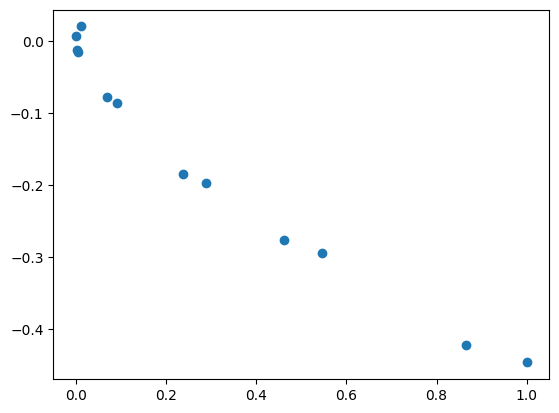

In [36]:
efficacies, means, normalized = zip(*epistasis_dict.values())
plt.plot(efficacies, means, "o")

## the efficacies need to be normalized

In [37]:
normalized

(0.0,
 0.031008484662844973,
 1.0,
 0.9444185691271721,
 0.4339028037712531,
 0.4057760168366674,
 0.6143328065207803,
 0.6548065991789912,
 0.1635469135288076,
 0.1802589656401329,
 0.021227978698099392,
 0.01552908217278511)

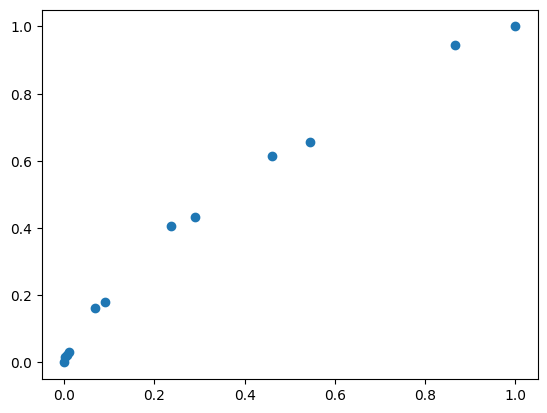

In [38]:
efficacies, means, normalized = zip(*epistasis_dict.values())
plt.plot(efficacies, normalized, "o")